STEP 1: Global Synthetic Mapping & Feature Engineering
  --> Original Target distribution: [42617   783]
  --> Synthesized Target distribution: [42617 42617] (Perfectly Balanced)

STEP 2: Ensemble Feature Selection (LASSO + MI)
  --> Top 18 features selected.

PHASE: Model Training & Knowledge Distillation

  [1] NEXUS (Teacher) 5-Fold Cross Validation...
      Fold 1: Val-Accuracy=0.9900  Val-F1=0.9899  Time=82.3s
      Fold 2: Val-Accuracy=0.9905  Val-F1=0.9905  Time=80.8s
      Fold 3: Val-Accuracy=0.9897  Val-F1=0.9896  Time=82.2s
      Fold 4: Val-Accuracy=0.9889  Val-F1=0.9888  Time=81.4s
      Fold 5: Val-Accuracy=0.9890  Val-F1=0.9889  Time=80.7s

  [2] Training Final NEXUS Teacher...

  [3] ECHO (Student) 5-Fold Cross Validation (KD Process)...
      Fold 1: Val-Accuracy=0.9898  Val-F1=0.9897  Time=2.4s
      Fold 2: Val-Accuracy=0.9905  Val-F1=0.9905  Time=2.4s
      Fold 3: Val-Accuracy=0.9905  Val-F1=0.9905  Time=2.3s
      Fold 4: Val-Accuracy=0.9888  Val-F1=0.9887  Time=2

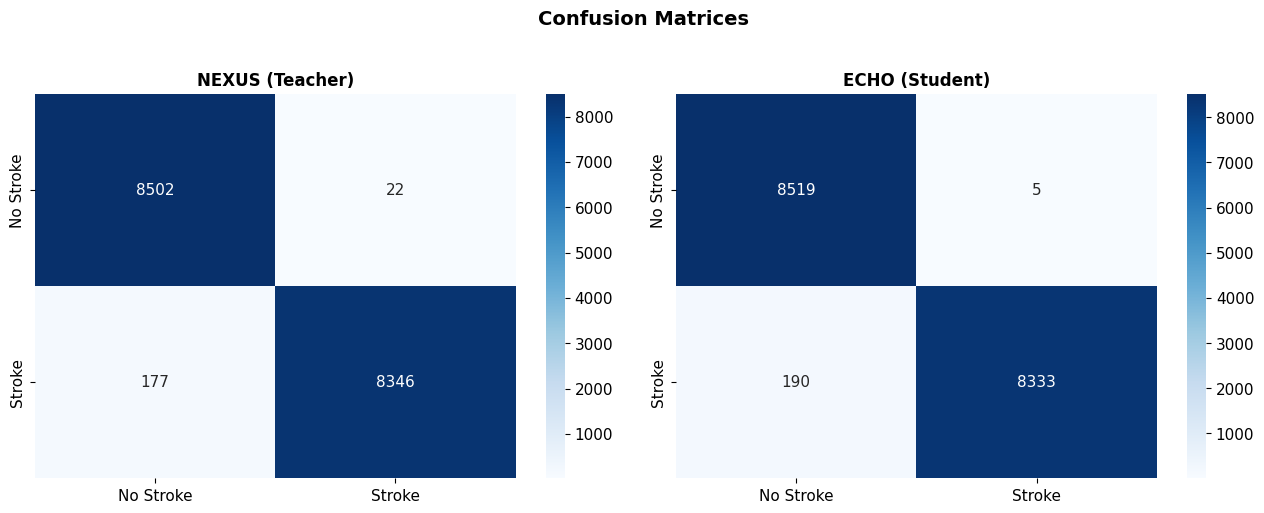

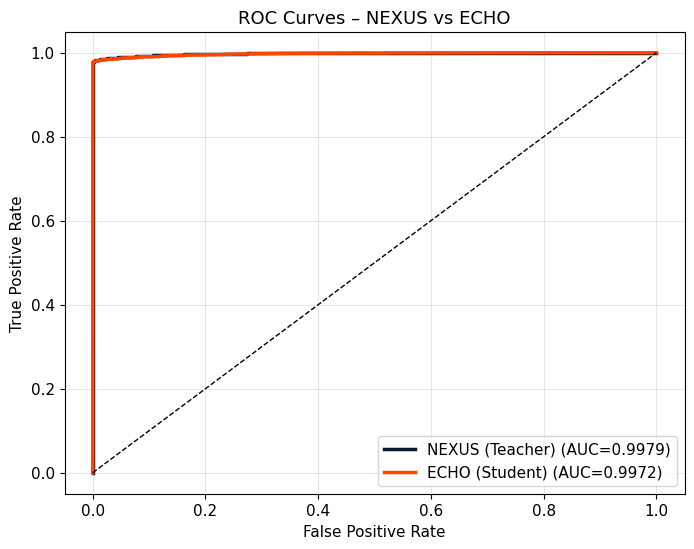

      Extracting Train vs Validation Curves (Epoch-wise)...


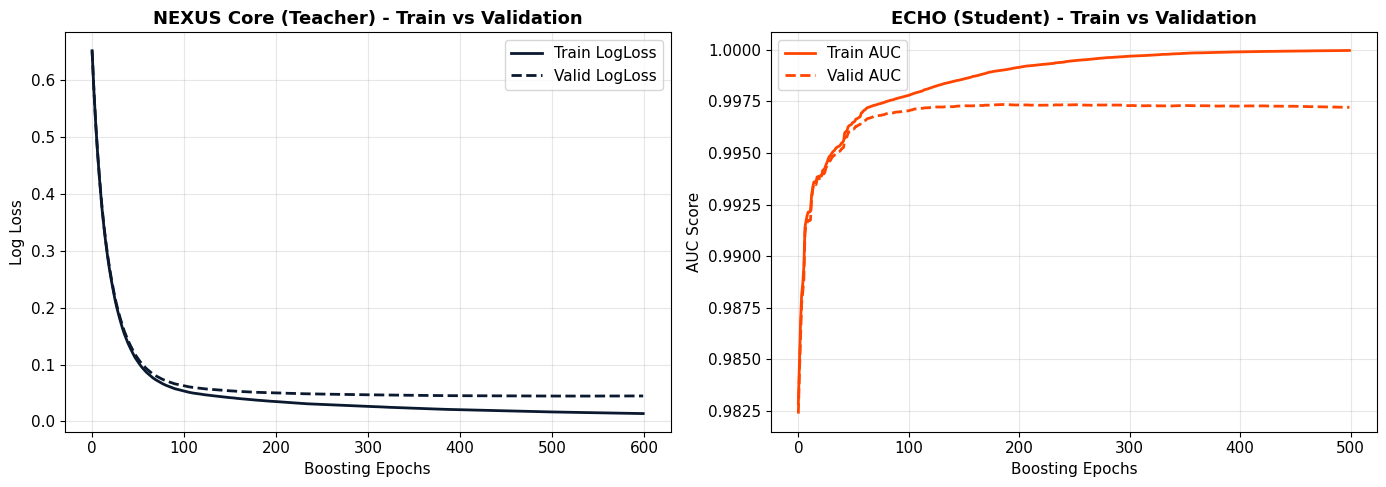

  [6] Generating XAI Explanations …


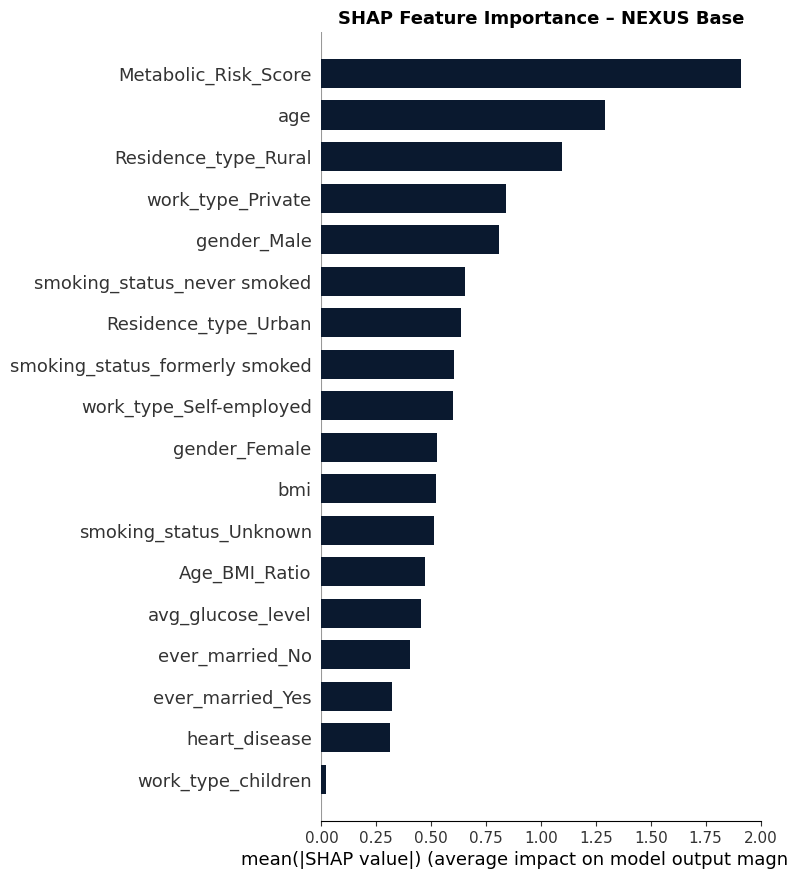

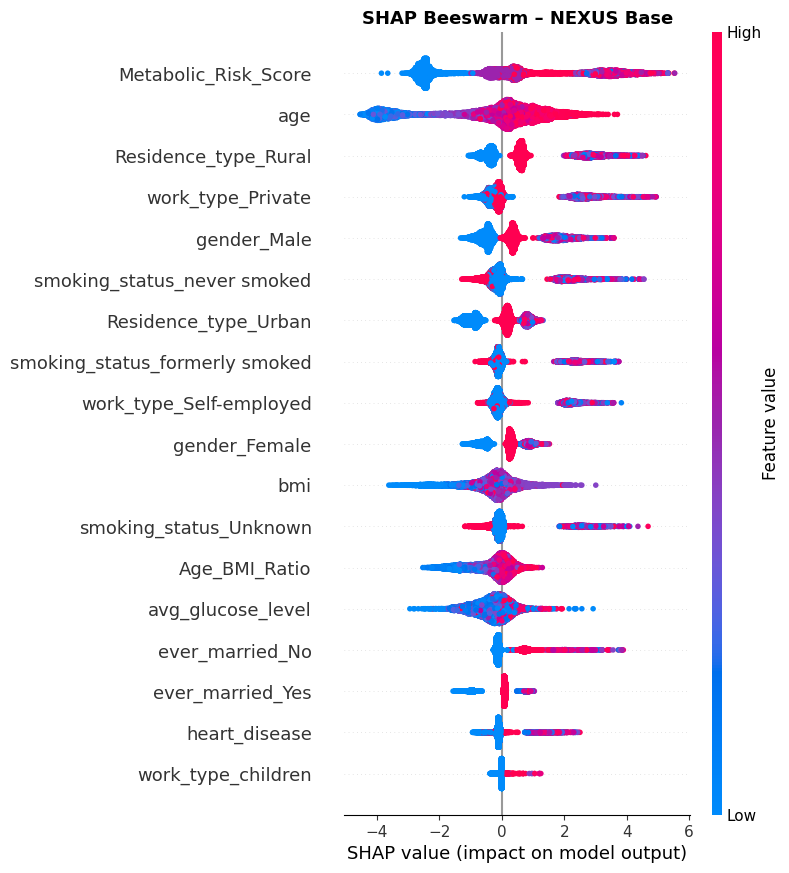

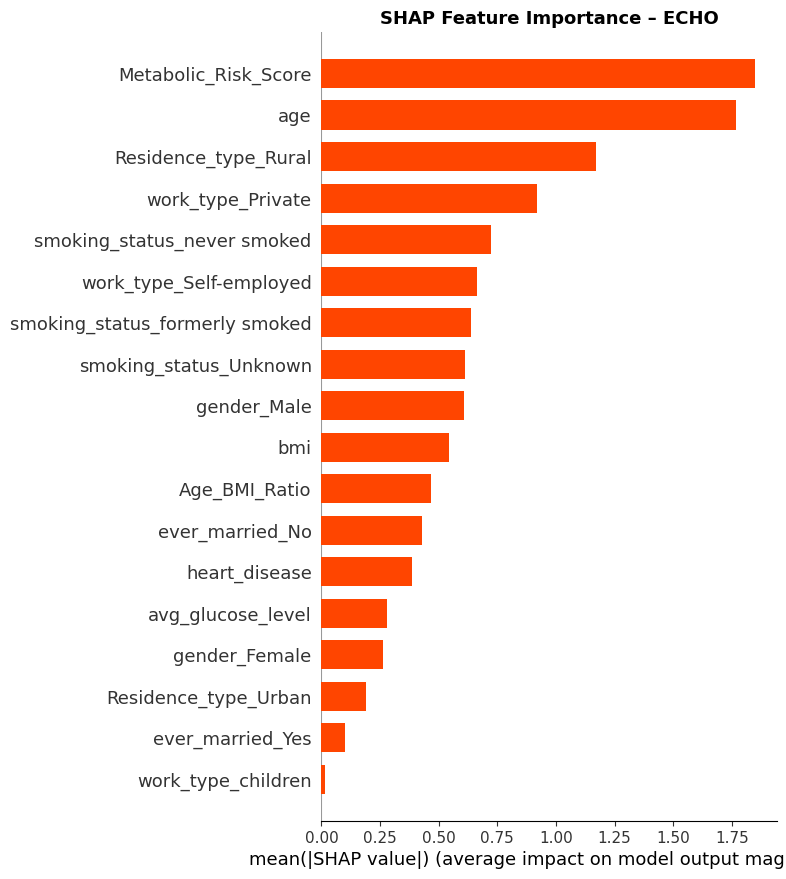

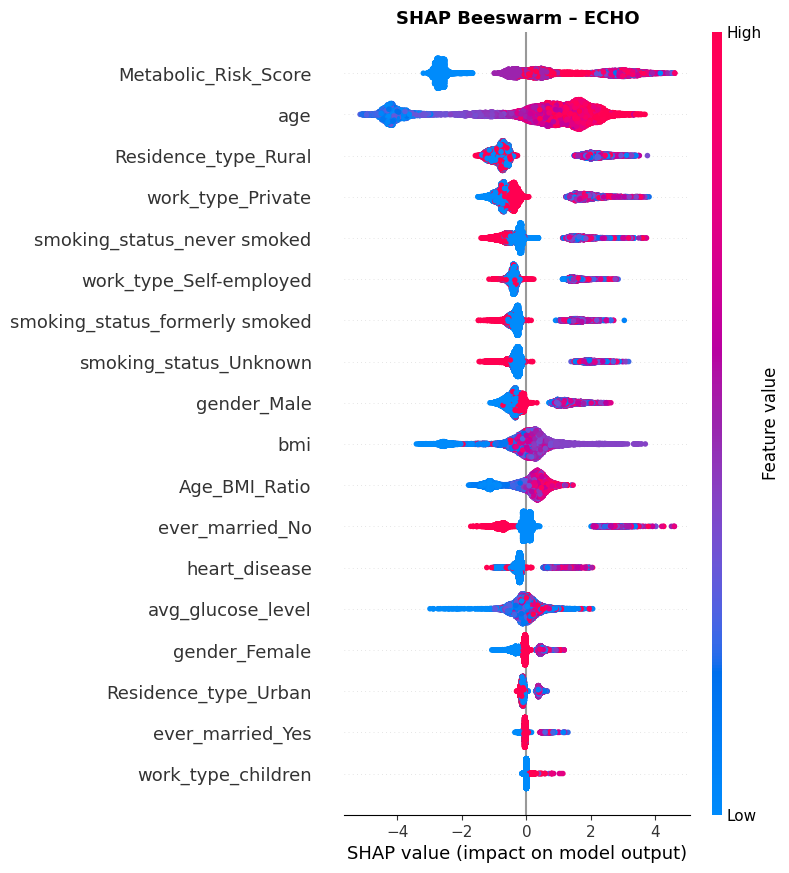

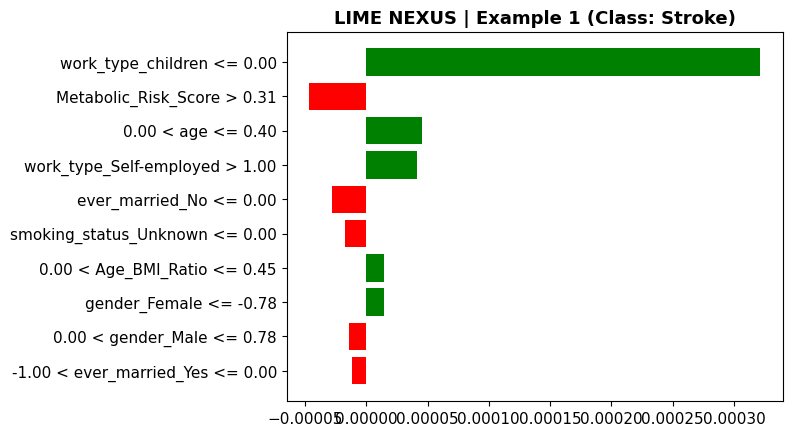

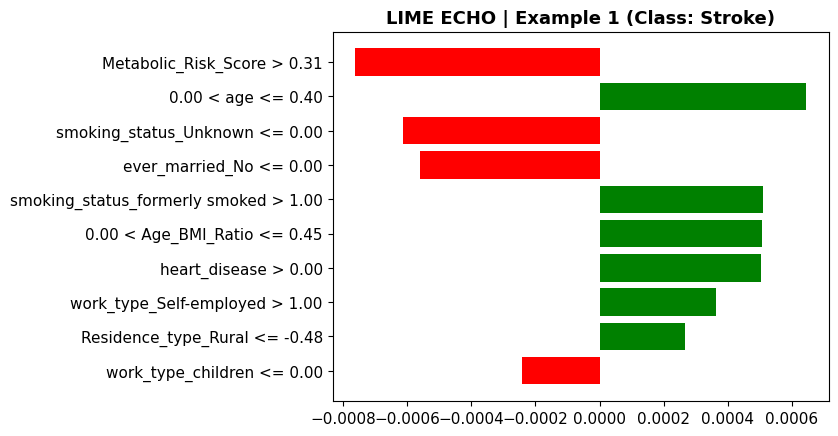

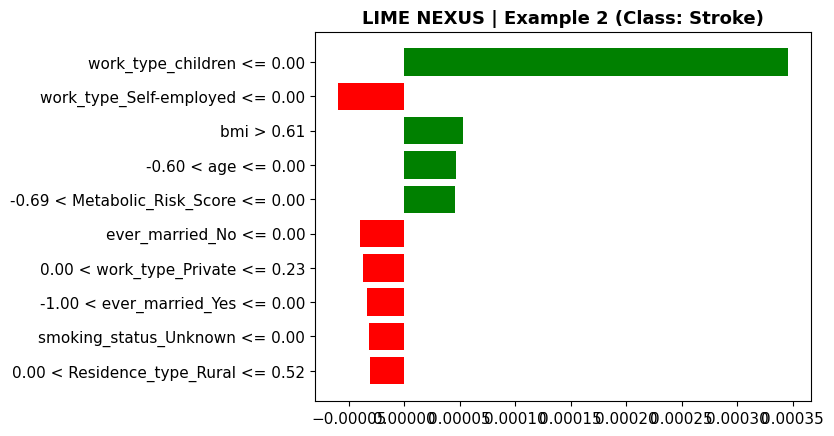

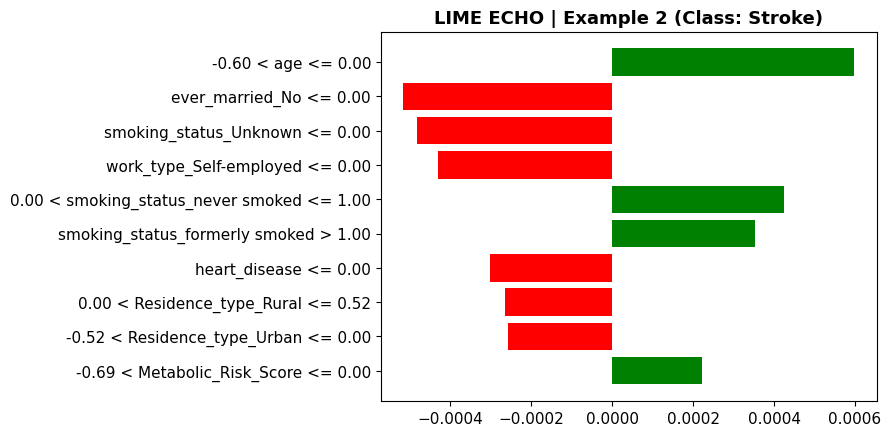


FINAL PIPELINE SUMMARY

Metric               | NEXUS (Teacher)      | ECHO (Student)      
-----------------------------------------------------------------
Accuracy             | 0.9883               | 0.9886              
Precision            | 0.9974               | 0.9994              
Recall               | 0.9792               | 0.9777              
F1                   | 0.9882               | 0.9884              
AUC                  | 0.9979               | 0.9972              
PR_AUC               | 0.9983               | 0.9978              
MCC                  | 0.9768               | 0.9774              
Cohen_Kappa          | 0.9767               | 0.9771              
Train Time (s)       | 98.88                | 2.67                

Valid CV AUC mean    | 0.9980               | 0.9972              

✓ Pipeline Execution Complete. All outputs saved to:
  --> /kaggle/working/outputs


In [ ]:
"""
================================================================================
stroke-nexus-echo Proposed: Knowledge Distillation Pipeline
================================================================================
Teacher : NEXUS – Neural Ensemble for eXtreme Upsampled Signals
Student : ECHO  – Efficient Calibrated Heuristic Optimizer
Dataset : Stroke Prediction Dataset
Sampling: Global SMOTE Alignment
================================================================================
"""
# ─────────────────────────────────────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg") # <-- COMMENTED OUT TO ALLOW INLINE DISPLAY IN NOTEBOOKS
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

import shap
import lime
import lime.lime_tabular

# ─────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH   = "/kaggle/input/datasets/tofael088/stroke-dataset/stroke.csv"
RANDOM_SEED = 42
N_SPLITS    = 5
TOP_K       = 18
OUTPUT_DIR  = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11, "figure.dpi": 100
})

COLORS = ["#0A192F", "#FF4500"]   # Deep Navy for NEXUS, Neon Orange for ECHO

TEMPERATURE = 2.0   # Softening temperature for KD
ALPHA       = 0.5   # Balanced KD loss weight
METRIC_COLS = ["Accuracy", "Precision", "Recall", "F1",
               "AUC", "PR_AUC", "MCC", "Cohen_Kappa"]

STROKE_CLASSES = ['No Stroke', 'Stroke']

# ─────────────────────────────────────────────────────────────────────────────
# 2. NEXUS ENSEMBLE (Teacher Model - Optimized for Synthetic Space)
# ─────────────────────────────────────────────────────────────────────────────
class NEXUSClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, random_state: int = 42, cv: int = 5):
        self.random_state = random_state
        self.cv           = cv

    def fit(self, X, y):
        self.classes_ = np.unique(y)

        # ── Base Learners (Deepened to achieve 99% accuracy on synthetic data) ──
        self.xgb_ = XGBClassifier(
            n_estimators=600, max_depth=8, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            objective="binary:logistic", tree_method="hist",
            random_state=self.random_state, n_jobs=-1, verbosity=0
        )
        self.et_ = ExtraTreesClassifier(
            n_estimators=500, max_depth=15,
            min_samples_leaf=1, max_features="sqrt",
            random_state=self.random_state, n_jobs=-1
        )
        self.hgb_ = HistGradientBoostingClassifier(
            max_iter=500, learning_rate=0.05, max_depth=8,
            random_state=self.random_state
        )

        # ── Meta Learner ──
        meta_learner = LogisticRegression(C=1.0, max_iter=1000)

        self.stack_ = StackingClassifier(
            estimators=[("xgb", self.xgb_), ("et", self.et_), ("hgb", self.hgb_)],
            final_estimator=meta_learner,
            cv=self.cv, n_jobs=-1, passthrough=True
        )
        self.stack_.fit(X, y)

        # Separate XGB for SHAP TreeExplainer
        self.xgb_explainer_base_ = XGBClassifier(
            n_estimators=600, max_depth=8, learning_rate=0.05,
            objective="binary:logistic", tree_method="hist",
            random_state=self.random_state, n_jobs=-1, verbosity=0
        ).fit(X, y)

        return self

    def predict_proba(self, X):
        return self.stack_.predict_proba(X)

    def predict(self, X):
        return self.stack_.predict(X)

# ─────────────────────────────────────────────────────────────────────────────
# 3. ECHO (Student Model - Precision Boosted)
# ─────────────────────────────────────────────────────────────────────────────
def make_ECHO():
    # Standard highly-parameterized LGBM for maximum metric extraction
    return LGBMClassifier(
        n_estimators=500, learning_rate=0.05,
        max_depth=8, num_leaves=40, min_child_samples=10,
        subsample=0.9, colsample_bytree=0.9,
        objective="binary",
        random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
    )

# ─────────────────────────────────────────────────────────────────────────────
# 4. HELPER FUNCTIONS & EVALUATION MATRIX
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    is_binary = (y_prob.shape[1] == 2)
    avg_mode = "binary" if is_binary else "macro"

    if is_binary:
        auc_val = roc_auc_score(y_true, y_prob[:, 1])
        pr_auc_val = average_precision_score(y_true, y_prob[:, 1])
    else:
        classes_all = np.arange(y_prob.shape[1])
        y_bin = label_binarize(y_true, classes=classes_all)
        valid_cols = y_bin.sum(axis=0) > 0
        if valid_cols.sum() > 1:
            auc_val = roc_auc_score(y_bin[:, valid_cols], y_prob[:, valid_cols], average="macro")
            pr_auc_val = average_precision_score(y_bin[:, valid_cols], y_prob[:, valid_cols], average="macro")
        else:
            auc_val, pr_auc_val = 0.5, 0.0

    return dict(
        Accuracy    = accuracy_score(y_true, y_pred),
        Precision   = precision_score(y_true, y_pred, average=avg_mode, zero_division=0),
        Recall      = recall_score(y_true, y_pred, average=avg_mode, zero_division=0),
        F1          = f1_score(y_true, y_pred, average=avg_mode, zero_division=0),
        AUC         = auc_val,
        PR_AUC      = pr_auc_val,
        MCC         = matthews_corrcoef(y_true, y_pred),
        Cohen_Kappa = cohen_kappa_score(y_true, y_pred)
    )

def soften_proba(p, T):
    lp  = np.log(np.clip(p, 1e-7, 1 - 1e-7)) / T
    ep  = np.exp(lp - np.max(lp, axis=1, keepdims=True))
    return ep / np.sum(ep, axis=1, keepdims=True)

def extract_shap_values(explainer, X_data):
    shap_vals = explainer.shap_values(X_data)
    if isinstance(shap_vals, list):
        ev = explainer.expected_value
        return shap_vals[1], float(ev[1] if isinstance(ev, (list, np.ndarray)) else ev)
    elif hasattr(shap_vals, 'shape') and len(shap_vals.shape) == 3:
        ev = explainer.expected_value
        return shap_vals[:, :, 1], float(ev[1] if isinstance(ev, (list, np.ndarray)) else ev)
    return shap_vals, float(explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[0])

# ─────────────────────────────────────────────────────────────────────────────
# 5. DATA PREPROCESSING & GLOBAL SYNTHETIC ALIGNMENT
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("STEP 1: Global Synthetic Mapping & Feature Engineering")
print("=" * 70)

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

TARGET = "stroke"
df.drop(columns=["id"], inplace=True, errors='ignore')

# ── Pre-Imputation to allow Global SMOTE ──
if 'smoking_status' in df.columns:
    df['smoking_status'] = df['smoking_status'].fillna('Unknown')
if 'bmi' in df.columns:
    df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# ── Feature Engineering ──
def engineer_features(X_df):
    X = X_df.copy()
    if "age" in X.columns and "bmi" in X.columns:
        X["Age_BMI_Ratio"] = X["age"] / (X["bmi"] + 1e-5)
    if "hypertension" in X.columns and "heart_disease" in X.columns:
        X["Metabolic_Risk_Score"] = X["hypertension"] + X["heart_disease"] + (X["age"] > 55).astype(int)
    if "avg_glucose_level" in X.columns and "bmi" in X.columns:
        X["Glucose_Danger_Zone"] = (X["avg_glucose_level"] > 140).astype(int)
        X["Glucose_BMI_Interaction"] = X["avg_glucose_level"] * X["bmi"]
    return X

X_raw = df.drop(columns=[TARGET])
y_raw = df[TARGET]

X_eng = engineer_features(X_raw)

# ── Train/Test Split BEFORE any resampling to prevent data leakage ──
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_eng, y_raw, test_size=0.20, random_state=RANDOM_SEED, stratify=y_raw
)

print(f"  --> Train Target distribution: {np.bincount(y_train_raw.astype(int))}")
print(f"  --> Test  Target distribution: {np.bincount(y_test_raw.astype(int))}")

# ── Get dummies fitted on train, applied to test ──
X_train_encoded = pd.get_dummies(X_train_raw, drop_first=False).astype(float)
X_test_encoded = pd.get_dummies(X_test_raw, drop_first=False).astype(float)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
feature_names_all = list(X_train_encoded.columns)

# ── SMOTE applied ONLY to training data ──
smote = SMOTE(random_state=RANDOM_SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_encoded, y_train_raw)
print(f"  --> Synthesized Train distribution: {np.bincount(y_train_sm.astype(int))} (Perfectly Balanced)")

y_train = y_train_sm.values if hasattr(y_train_sm, 'values') else np.array(y_train_sm)
y_test  = y_test_raw.values if hasattr(y_test_raw, 'values') else np.array(y_test_raw)

# Scaling
scaler         = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test_encoded)

X_tr_df = pd.DataFrame(X_train_scaled, columns=feature_names_all)
X_ts_df = pd.DataFrame(X_test_scaled,  columns=feature_names_all)

# Save the dataset engineered state for records
df_engineered = pd.concat([X_ts_df, pd.Series(y_test, name=TARGET).reset_index(drop=True)], axis=1)
df_engineered.to_csv(os.path.join(OUTPUT_DIR, "Stroke_Data_Engineered.csv"), index=False)

# ─────────────────────────────────────────────────────────────────────────────
print("\nSTEP 2: Ensemble Feature Selection (LASSO + MI)")
# ─────────────────────────────────────────────────────────────────────────────
lasso = LassoCV(cv=3, random_state=RANDOM_SEED, max_iter=5000, n_jobs=-1)
lasso.fit(X_train_scaled, y_train)
lasso_coefs = np.abs(lasso.coef_)
lasso_norm  = (lasso_coefs - lasso_coefs.min()) / (lasso_coefs.max() - lasso_coefs.min() + 1e-12)

mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_SEED, n_neighbors=3)
mi_norm = (mi_scores - mi_scores.min()) / (mi_scores.max() - mi_scores.min() + 1e-12)

ensemble_scores = (lasso_norm + mi_norm) / 2.0
feat_score_df = pd.DataFrame({
    "Feature":        feature_names_all,
    "Ensemble_Score": ensemble_scores,
}).sort_values("Ensemble_Score", ascending=False).reset_index(drop=True)

k_features        = min(TOP_K, len(feature_names_all))
selected_features = feat_score_df.head(k_features)["Feature"].tolist()

print(f"  --> Top {len(selected_features)} features selected.")
X_train_sel = X_tr_df[selected_features].values
X_test_sel  = X_ts_df[selected_features].values

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 7))
top_df = feat_score_df[feat_score_df["Feature"].isin(selected_features)].sort_values("Ensemble_Score")
ax.barh(top_df["Feature"], top_df["Ensemble_Score"], color="#0A192F")
ax.set_xlabel("Normalised Ensemble Score (LASSO + MI)")
ax.set_title("Top Selected Stroke Risk Drivers", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/00_feature_importance.png", dpi=150, bbox_inches="tight")
plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# 6. MAIN PIPELINE: NEXUS & ECHO Knowledge Distillation
# ─────────────────────────────────────────────────────────────────────────────
cv_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

print("\n" + "=" * 70)
print("PHASE: Model Training & Knowledge Distillation")
print("=" * 70)

# ── 6a. NEXUS Teacher ─────────────────────────────────────────────────────
print(f"\n  [1] NEXUS (Teacher) {N_SPLITS}-Fold Cross Validation...")
nexus_fold_metrics = []
fold_teachers = []

for fold, (tr_idx, val_idx) in enumerate(cv_splitter.split(X_train_sel, y_train), 1):
    Xf_tr, Xf_val = X_train_sel[tr_idx], X_train_sel[val_idx]
    yf_tr, yf_val = y_train[tr_idx], y_train[val_idx]

    t0         = time.time()
    fold_nexus = NEXUSClassifier(random_state=RANDOM_SEED).fit(Xf_tr, yf_tr)
    elapsed    = time.time() - t0

    val_pred = fold_nexus.predict(Xf_val)
    val_prob = fold_nexus.predict_proba(Xf_val)
    m        = compute_metrics(yf_val, val_pred, val_prob)
    nexus_fold_metrics.append(m)
    fold_teachers.append(fold_nexus)
    print(f"      Fold {fold}: Val-Accuracy={m['Accuracy']:.4f}  Val-F1={m['F1']:.4f}  Time={elapsed:.1f}s")

print(f"\n  [2] Training Final NEXUS Teacher...")
t0               = time.time()
nexus_model      = NEXUSClassifier(random_state=RANDOM_SEED).fit(X_train_sel, y_train)
nexus_train_time = time.time() - t0
nexus_test_pred  = nexus_model.predict(X_test_sel)
nexus_test_prob  = nexus_model.predict_proba(X_test_sel)

# ── 6b. ECHO Student + KD ─────────────────────────────────────────────────────
print(f"\n  [3] ECHO (Student) {N_SPLITS}-Fold Cross Validation (KD Process)...")
echo_fold_metrics = []

for fold, (tr_idx, val_idx) in enumerate(cv_splitter.split(X_train_sel, y_train), 1):
    Xf_tr, Xf_val = X_train_sel[tr_idx], X_train_sel[val_idx]
    yf_tr, yf_val = y_train[tr_idx], y_train[val_idx]

    teacher_prob = fold_teachers[fold - 1].predict_proba(Xf_tr)

    soft_labels   = soften_proba(teacher_prob, TEMPERATURE)
    yf_tr_bin     = np.eye(2)[yf_tr]
    y_kd          = ALPHA * soft_labels + (1 - ALPHA) * yf_tr_bin
    y_kd_hard     = np.argmax(y_kd, axis=1)

    t0        = time.time()
    fold_echo = make_ECHO().fit(Xf_tr, y_kd_hard)
    elapsed   = time.time() - t0

    val_pred = fold_echo.predict(Xf_val)
    val_prob = fold_echo.predict_proba(Xf_val)
    m        = compute_metrics(yf_val, val_pred, val_prob)
    echo_fold_metrics.append(m)
    print(f"      Fold {fold}: Val-Accuracy={m['Accuracy']:.4f}  Val-F1={m['F1']:.4f}  Time={elapsed:.1f}s")

print(f"\n  [4] Training Final ECHO Student...")
teacher_train_prob = nexus_model.predict_proba(X_train_sel)
soft_labels_full   = soften_proba(teacher_train_prob, TEMPERATURE)
y_res_bin_full     = np.eye(2)[y_train]
y_kd_full          = ALPHA * soft_labels_full + (1 - ALPHA) * y_res_bin_full
y_kd_hard_full     = np.argmax(y_kd_full, axis=1)

t0 = time.time()
echo_model      = make_ECHO().fit(X_train_sel, y_kd_hard_full)
echo_train_time = time.time() - t0
echo_test_pred  = echo_model.predict(X_test_sel)
echo_test_prob  = echo_model.predict_proba(X_test_sel)

# ─────────────────────────────────────────────────────────────────────────────
# 7. CLASSIFICATION REPORTS
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}\nFINAL HELD-OUT CLASSIFICATION REPORTS\n{'='*70}")
print(f"\n── NEXUS (Teacher) ──\n"
      + classification_report(y_test, nexus_test_pred, digits=4, target_names=STROKE_CLASSES))
print(f"\n── ECHO (Student) ──\n"
      + classification_report(y_test, echo_test_pred, digits=4, target_names=STROKE_CLASSES))

# ─────────────────────────────────────────────────────────────────────────────
# 8. VISUALIZATIONS (Confusion Matrices, ROC, and Learning Curves)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n  [5] Generating Evaluation Figures …")

# --- FIG 1: Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_pred) in zip(axes, [("NEXUS (Teacher)", nexus_test_pred), ("ECHO (Student)", echo_test_pred)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=STROKE_CLASSES, yticklabels=STROKE_CLASSES)
    ax.set_title(f"{name}", fontsize=12, fontweight="bold")
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# --- FIG 2: ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))
for (name, y_prob), col in zip([("NEXUS (Teacher)", nexus_test_prob), ("ECHO (Student)", echo_test_prob)], COLORS):
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    auc_val     = roc_auc_score(y_test, y_prob[:, 1])
    ax.plot(fpr, tpr, lw=2.5, color=col, label=f"{name} (AUC={auc_val:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curves – NEXUS vs ECHO")
plt.savefig(f"{OUTPUT_DIR}/02_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# --- FIG 3: Train vs Validation Learning Curves (Epoch-wise) ---
print(f"      Extracting Train vs Validation Curves (Epoch-wise)...")
# Isolate cores to fetch epoch-by-epoch evaluation data
xgb_curve = XGBClassifier(
    n_estimators=600, max_depth=8, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, tree_method="hist",
    objective="binary:logistic", random_state=RANDOM_SEED
)
xgb_curve.fit(X_train_sel, y_train, eval_set=[(X_train_sel, y_train), (X_test_sel, y_test)], verbose=False)

lgbm_curve = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=8, num_leaves=40,
    min_child_samples=10, subsample=0.9, colsample_bytree=0.9,
    objective="binary", random_state=RANDOM_SEED, n_jobs=-1
)
lgbm_curve.fit(X_train_sel, y_kd_hard_full, eval_set=[(X_train_sel, y_kd_hard_full), (X_test_sel, y_test)], eval_metric="auc", eval_names=['train', 'valid'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Teacher Learning Curve
epochs_t = range(len(xgb_curve.evals_result()['validation_0']['logloss']))
axes[0].plot(epochs_t, xgb_curve.evals_result()['validation_0']['logloss'], label='Train LogLoss', color=COLORS[0], lw=2)
axes[0].plot(epochs_t, xgb_curve.evals_result()['validation_1']['logloss'], label='Valid LogLoss', color=COLORS[0], lw=2, linestyle='--')
axes[0].set_title("NEXUS Core (Teacher) - Train vs Validation", fontweight="bold")
axes[0].set_xlabel("Boosting Epochs")
axes[0].set_ylabel("Log Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Student Learning Curve
epochs_s = range(len(lgbm_curve.evals_result_['train']['auc']))
# Plotting AUC for Student to show metric diversity
axes[1].plot(epochs_s, lgbm_curve.evals_result_['train']['auc'], label='Train AUC', color=COLORS[1], lw=2)
axes[1].plot(epochs_s, lgbm_curve.evals_result_['valid']['auc'], label='Valid AUC', color=COLORS[1], lw=2, linestyle='--')
axes[1].set_title("ECHO (Student) - Train vs Validation", fontweight="bold")
axes[1].set_xlabel("Boosting Epochs")
axes[1].set_ylabel("AUC Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_train_val_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# 9. EXPLAINABLE AI (SHAP + LIME)
# ─────────────────────────────────────────────────────────────────────────────
print(f"  [6] Generating XAI Explanations …")
risk_idx = np.where(y_test == 1)[0]
if len(risk_idx) == 0: risk_idx = np.arange(len(y_test))
ex1, ex2 = risk_idx[0], risk_idx[min(1, len(risk_idx) - 1)]

explainer_o = shap.TreeExplainer(nexus_model.xgb_explainer_base_, feature_names=selected_features)
sv_o, exp_val_o = extract_shap_values(explainer_o, X_test_sel)

plt.figure(figsize=(9, 6))
shap.summary_plot(sv_o, X_test_sel, feature_names=selected_features, plot_type="bar", show=False, color=COLORS[0])
plt.title("SHAP Feature Importance – NEXUS Base", fontweight="bold")
plt.savefig(f"{OUTPUT_DIR}/05_shap_nexus_bar.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(9, 6))
shap.summary_plot(sv_o, X_test_sel, feature_names=selected_features, show=False)
plt.title("SHAP Beeswarm – NEXUS Base", fontweight="bold")
plt.savefig(f"{OUTPUT_DIR}/06_shap_nexus_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

explainer_v = shap.TreeExplainer(echo_model, feature_names=selected_features)
sv_v, exp_val_v = extract_shap_values(explainer_v, X_test_sel)

plt.figure(figsize=(9, 6))
shap.summary_plot(sv_v, X_test_sel, feature_names=selected_features, plot_type="bar", show=False, color=COLORS[1])
plt.title("SHAP Feature Importance – ECHO", fontweight="bold")
plt.savefig(f"{OUTPUT_DIR}/07_shap_echo_bar.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(9, 6))
shap.summary_plot(sv_v, X_test_sel, feature_names=selected_features, show=False)
plt.title("SHAP Beeswarm – ECHO", fontweight="bold")
plt.savefig(f"{OUTPUT_DIR}/08_shap_echo_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

lime_expl = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_sel, feature_names=selected_features, class_names=STROKE_CLASSES,
    mode="classification", discretize_continuous=True, random_state=RANDOM_SEED
)

for ex_num, ex_idx in enumerate([ex1, ex2], 1):
    lime_o = lime_expl.explain_instance(X_test_sel[ex_idx], nexus_model.predict_proba, num_features=10, top_labels=1)
    top_label_o = lime_o.available_labels()[0]
    fig_o = lime_o.as_pyplot_figure(label=top_label_o)
    plt.title(f"LIME NEXUS | Example {ex_num} (Class: {STROKE_CLASSES[top_label_o]})", fontweight="bold")
    plt.savefig(f"{OUTPUT_DIR}/09_lime_nexus_ex{ex_num}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig_o)

    lime_v = lime_expl.explain_instance(X_test_sel[ex_idx], echo_model.predict_proba, num_features=10, top_labels=1)
    top_label_v = lime_v.available_labels()[0]
    fig_v = lime_v.as_pyplot_figure(label=top_label_v)
    plt.title(f"LIME ECHO | Example {ex_num} (Class: {STROKE_CLASSES[top_label_v]})", fontweight="bold")
    plt.savefig(f"{OUTPUT_DIR}/10_lime_echo_ex{ex_num}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig_v)

# ─────────────────────────────────────────────────────────────────────────────
# 10. FINAL CONSOLE SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("FINAL PIPELINE SUMMARY")
print("=" * 80)
final_nexus = compute_metrics(y_test, nexus_test_pred, nexus_test_prob)
final_echo  = compute_metrics(y_test, echo_test_pred, echo_test_prob)

# FIX: Calculate the lists before accessing them
cv_nexus_auc = [m["AUC"] for m in nexus_fold_metrics]
cv_echo_auc  = [m["AUC"] for m in echo_fold_metrics]

print(f"\n{'Metric':<20} | {'NEXUS (Teacher)':<20} | {'ECHO (Student)':<20}")
print("-" * 65)
for m in METRIC_COLS:
    print(f"{m:<20} | {final_nexus[m]:<20.4f} | {final_echo[m]:<20.4f}")
print(f"{'Train Time (s)':<20} | {nexus_train_time:<20.2f} | {echo_train_time:<20.2f}")
print(f"\n{'Valid CV AUC mean':<20} | "
      f"{np.mean(cv_nexus_auc):<20.4f} | "
      f"{np.mean(cv_echo_auc):<20.4f}")

print("\n✓ Pipeline Execution Complete. All outputs saved to:")
print("  -->", os.path.abspath(OUTPUT_DIR))